<a href="https://colab.research.google.com/github/Laxmi0412/Customer-Churn-Retention-Analytics/blob/main/Customer-Churn-Retention-Analytics/notebooks/Telco_Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx


In [7]:
import pandas as pd
import os
print(os.listdir())
df = pd.read_excel("Telco_customer_churn.xlsx")

print(df.head())
print(df.shape)

['.config', 'Telco_customer_churn.xlsx', 'sample_data']
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless 

In [9]:
df.columns = df.columns.str.strip()

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nMissing Values")
print(df.isnull().sum())

First 5 Rows
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly

In [14]:
print(df.columns)

import pandas as pd

df = pd.read_excel("Telco_customer_churn.xlsx")

# Clean column names
df.columns = df.columns.str.strip()
print(df.head())

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles 

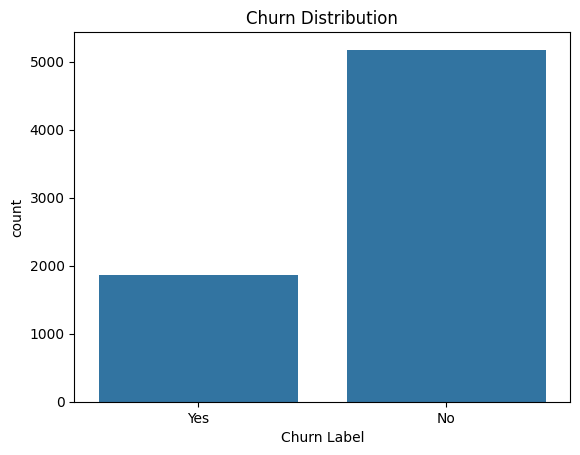

In [17]:

# Convert Total Charges correctly
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# Fill missing values
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn Label", data=df)
plt.title("Churn Distribution")
plt.show()

In [18]:
churn_rate = df["Churn Value"].mean() * 100
print("Churn Rate:", churn_rate)

Churn Rate: 26.536987079369588


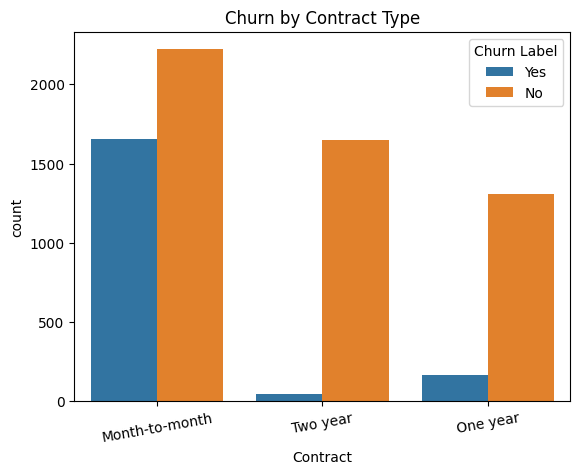

In [19]:
sns.countplot(x="Contract", hue="Churn Label", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=10)
plt.show()

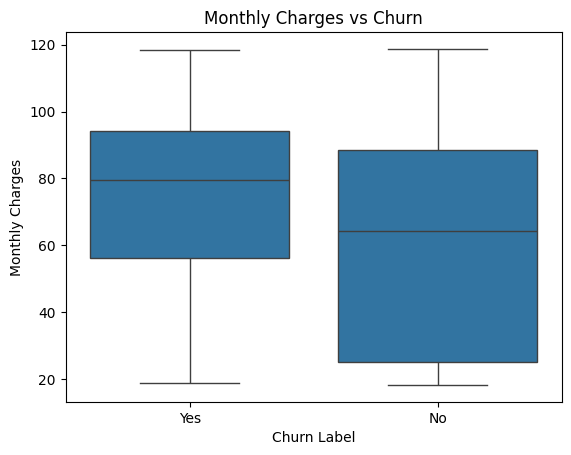

In [20]:
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

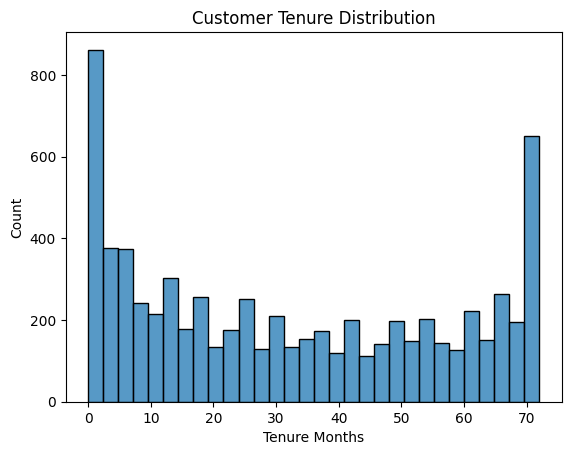

In [21]:
sns.histplot(df["Tenure Months"], bins=30)
plt.title("Customer Tenure Distribution")
plt.show()

In [22]:
def risk(x):
    if x <= 12:
        return "High Risk"
    elif x <= 36:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk Category"] = df["Tenure Months"].apply(risk)

print(df["Risk Category"].value_counts())

Risk Category
Low Risk       3001
High Risk      2186
Medium Risk    1856
Name: count, dtype: int64
